In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_img():
    blank_img =np.zeros((600,600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='MATH',org=(100,350), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [3]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

In [4]:
img = load_img()

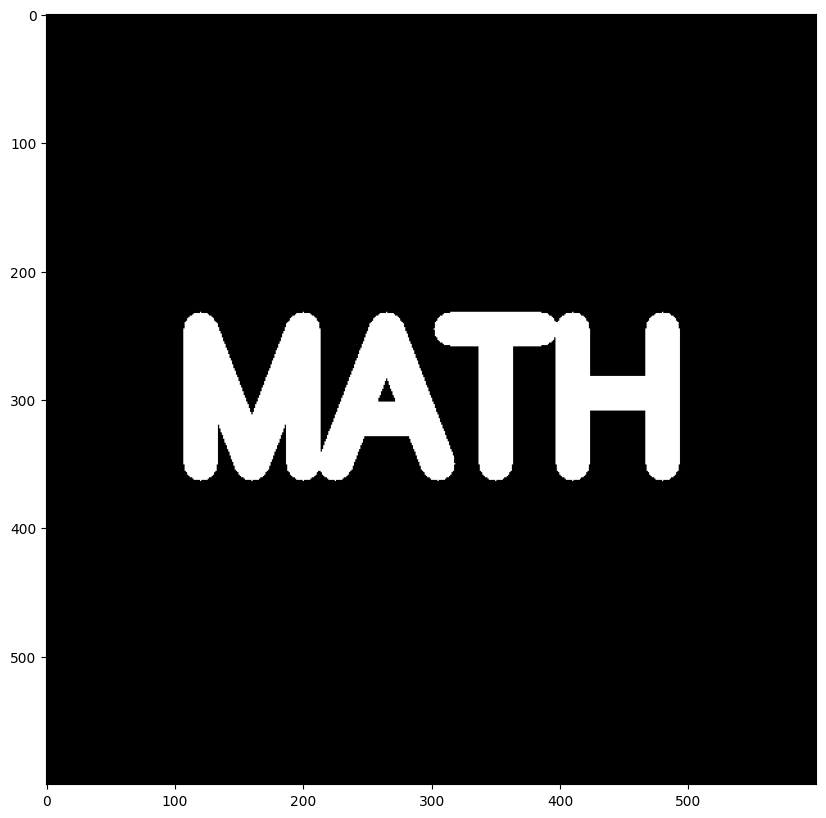

In [5]:
display_img(img)

In [19]:
kernel = np.ones((5,5),dtype=np.uint8)

In [20]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [6]:
white_noise = np.random.randint(low=0,high=2,size=(600,600))

In [7]:
white_noise

array([[1, 1, 0, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 1, 0],
       [1, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 1, ..., 1, 0, 1],
       [1, 1, 0, ..., 1, 1, 0],
       [0, 1, 1, ..., 0, 1, 0]], shape=(600, 600), dtype=int32)

In [8]:
img.max()

np.float64(255.0)

In [9]:
white_noise.max()

np.int32(1)

In [12]:
white_noise = white_noise*255

In [13]:
white_noise.shape

(600, 600)

In [14]:
white_noise

array([[255, 255,   0, ..., 255,   0, 255],
       [255, 255, 255, ..., 255, 255,   0],
       [255,   0,   0, ...,   0,   0, 255],
       ...,
       [  0,   0, 255, ..., 255,   0, 255],
       [255, 255,   0, ..., 255, 255,   0],
       [  0, 255, 255, ...,   0, 255,   0]], shape=(600, 600), dtype=int32)

In [15]:
noise_img = white_noise+img

In [16]:
noise_img

array([[255., 255.,   0., ..., 255.,   0., 255.],
       [255., 255., 255., ..., 255., 255.,   0.],
       [255.,   0.,   0., ...,   0.,   0., 255.],
       ...,
       [  0.,   0., 255., ..., 255.,   0., 255.],
       [255., 255.,   0., ..., 255., 255.,   0.],
       [  0., 255., 255., ...,   0., 255.,   0.]], shape=(600, 600))

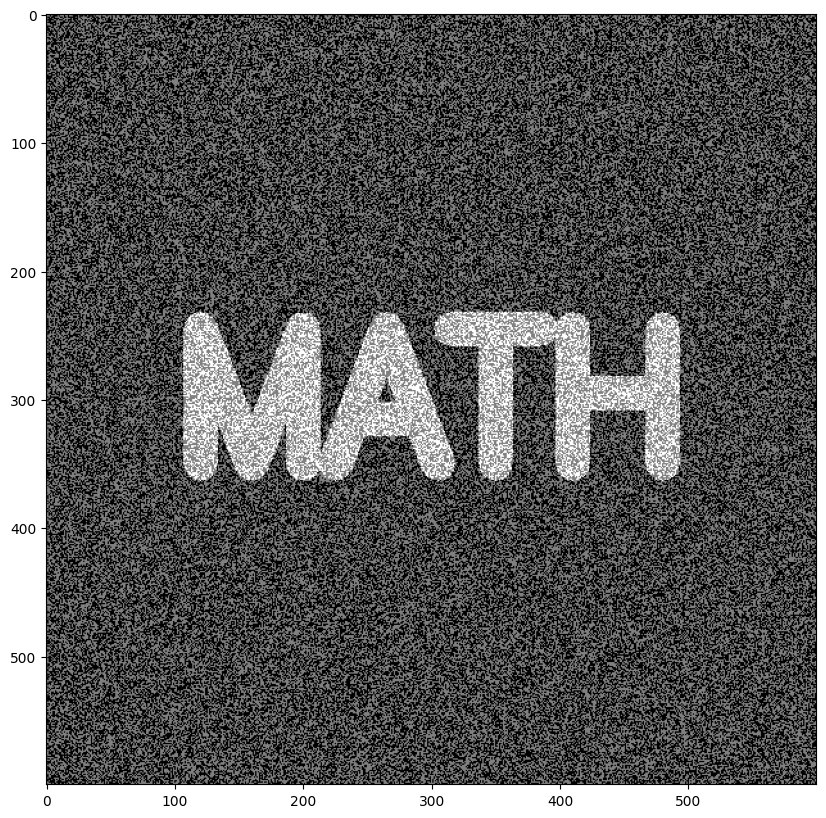

In [17]:
display_img(noise_img)

In [21]:
opening = cv2.morphologyEx(noise_img,cv2.MORPH_OPEN,kernel)

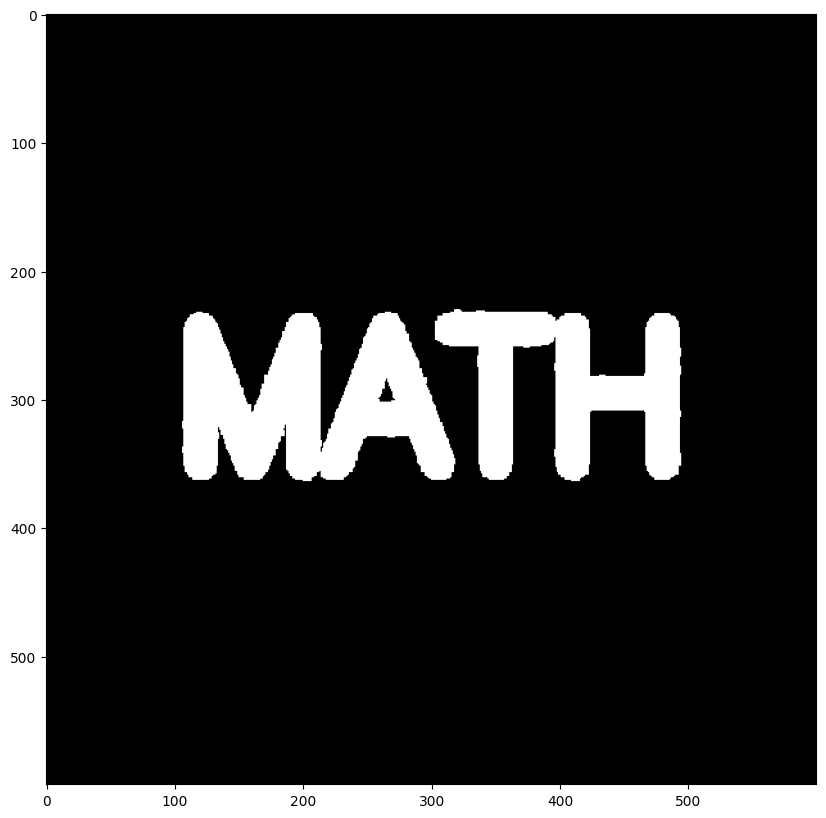

In [22]:
display_img(opening)

In [23]:
img = load_img()

In [24]:
black_noise = np.random.randint(low=0,high=2,size=(600,600))

In [25]:
black_noise

array([[0, 1, 1, ..., 0, 0, 1],
       [1, 1, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 1, 0],
       [1, 0, 1, ..., 0, 0, 1]], shape=(600, 600), dtype=int32)

In [26]:
img.max()

np.float64(255.0)

In [27]:
black_noise.max()

np.int32(1)

In [28]:
black_noise = black_noise * -255

In [29]:
black_noise.shape

(600, 600)

In [30]:
black_noise

array([[   0, -255, -255, ...,    0,    0, -255],
       [-255, -255, -255, ...,    0,    0,    0],
       [   0, -255,    0, ...,    0,    0,    0],
       ...,
       [   0,    0, -255, ..., -255,    0,    0],
       [-255,    0,    0, ..., -255, -255,    0],
       [-255,    0, -255, ...,    0,    0, -255]],
      shape=(600, 600), dtype=int32)

In [31]:
black_noise = black_noise + img

In [32]:
black_noise[black_noise==-255] = 0

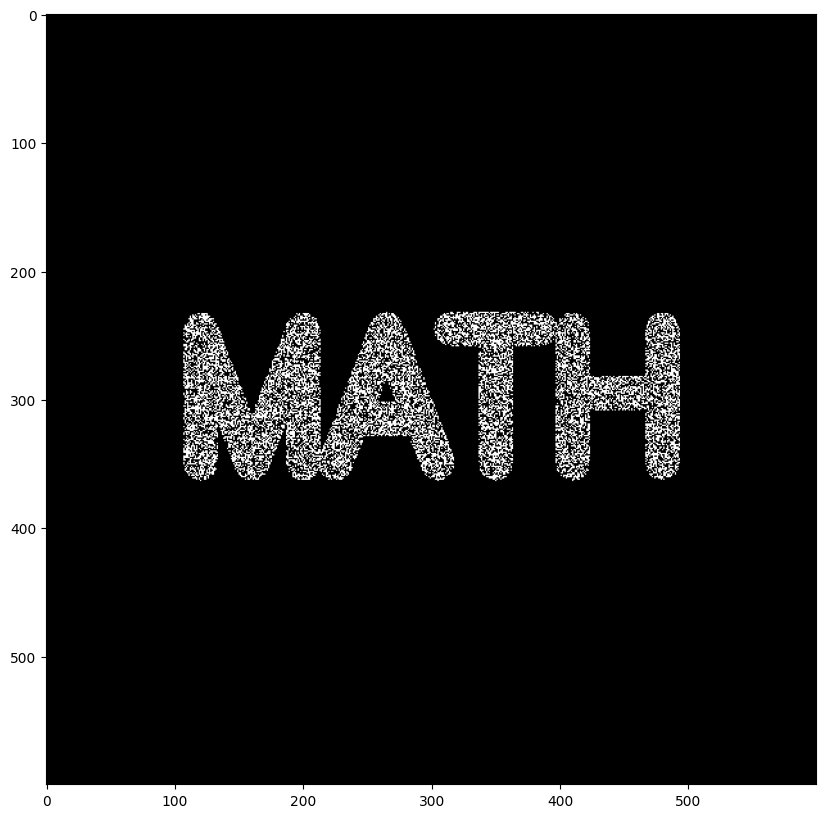

In [33]:
display_img(black_noise)

In [34]:
closing = cv2.morphologyEx(black_noise, cv2.MORPH_CLOSE, kernel)

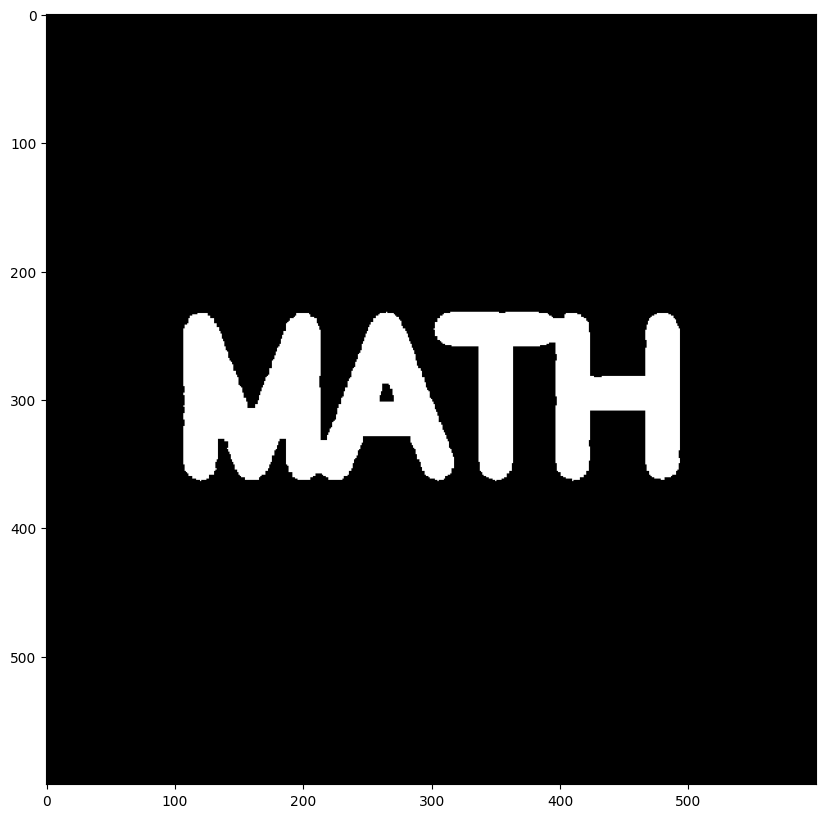

In [35]:
display_img(closing)